In [1]:
import pytensor
pytensor.config.cxx = "/usr/bin/clang++"

import pandas
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pymc as pm
import arviz as az

%matplotlib inline
%config InlineBackend.figure_format = "retina"

sns.set(rc={"figure.figsize" : (25, 15)})
sns.set(font_scale=2)
sns.set_style("ticks")

In [3]:
past_vote_df = pandas.read_excel(
    "https://docs.google.com/spreadsheets/d/1AZfxs2caMVdYPsiqiZJmX3P-CTq5Yewi3CAccvT7acw/export?format=xlsx",
    sheet_name="Past Vote", dtype={"FIPS" : str})
del past_vote_df["Weighted % D"]

In [4]:
coords = {
    "county" : past_vote_df["County"]
}

In [5]:
with pm.Model(coords=coords) as model:
    turnout_pct = pm.Beta("turnout_pct",
                          mu=past_vote_df[["% 2P Turnout 2021", "% 2P Turnout 2024"]].mean(axis=1),
                          sigma=past_vote_df[["% 2P Turnout 2021", "% 2P Turnout 2024"]].std(ddof=1, axis=1),
                          dims="county")

    turnout = pm.Binomial("turnout",
                          p=turnout_pct,
                          n=past_vote_df["Current RV"],
                          dims="county")

    prior_pct_D = pm.Beta("prior_pct_D",
                          mu=past_vote_df[["% Murphy 2P", "% Harris 2P"]].mean(axis=1),
                          sigma=past_vote_df[["% Murphy 2P", "% Harris 2P"]].std(ddof=1, axis=1),
                          dims="county")

    # prior_vote_D = pm.Deterministic("prior_vote_D", turnout * prior_pct_D, dims="county")

In [6]:
with model:
    idata = pm.sample()#extend_inferencedata=True)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [turnout_pct, prior_pct_D]
>Metropolis: [turnout]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


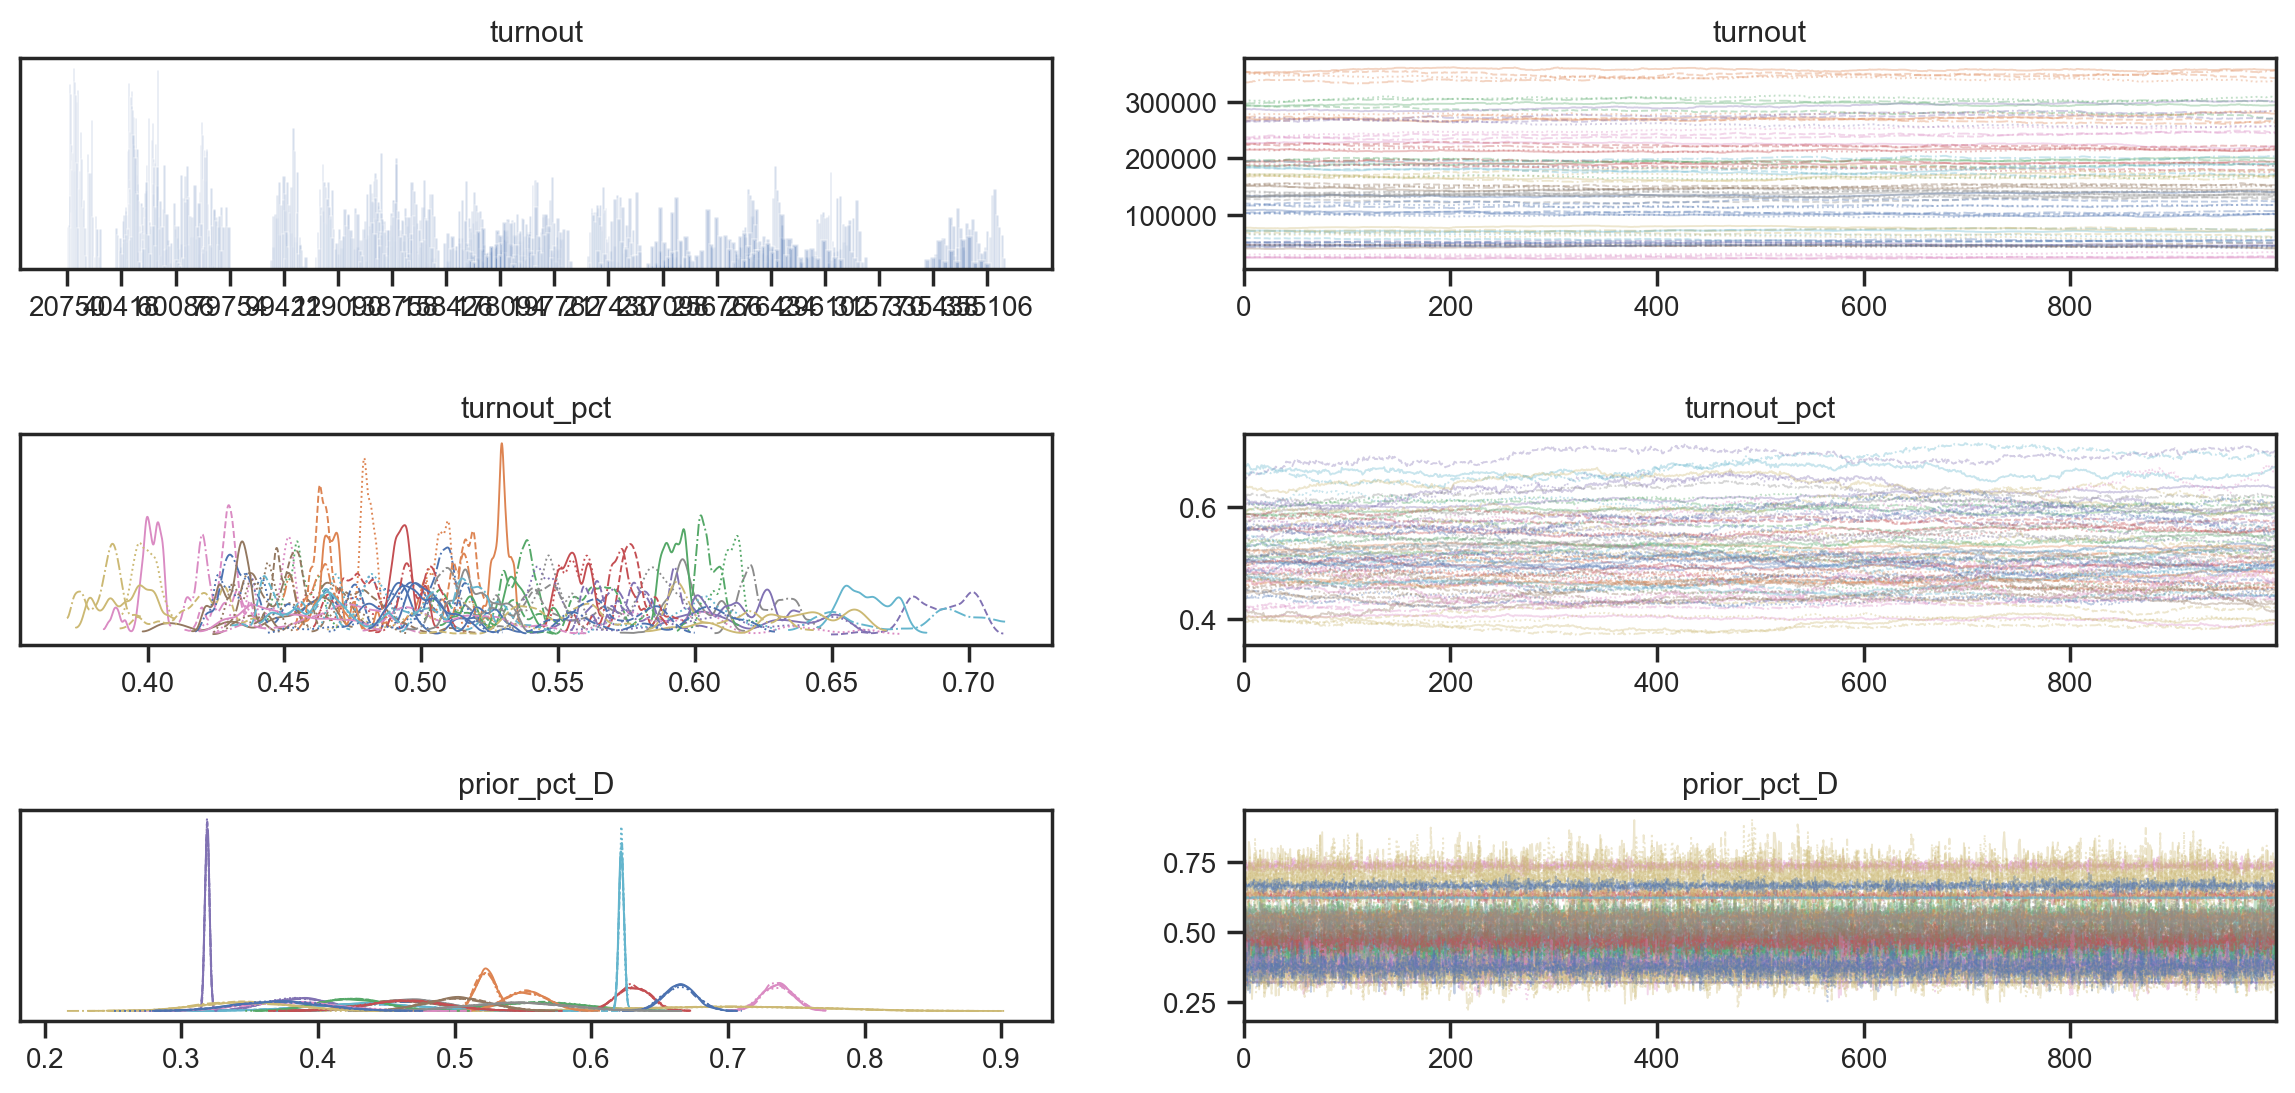

In [7]:
az.plot_trace(idata);
plt.tight_layout()

In [8]:
with model:
    pred_oos = pm.sample_posterior_predictive(idata, extend_inferencedata=True, predictions=True)

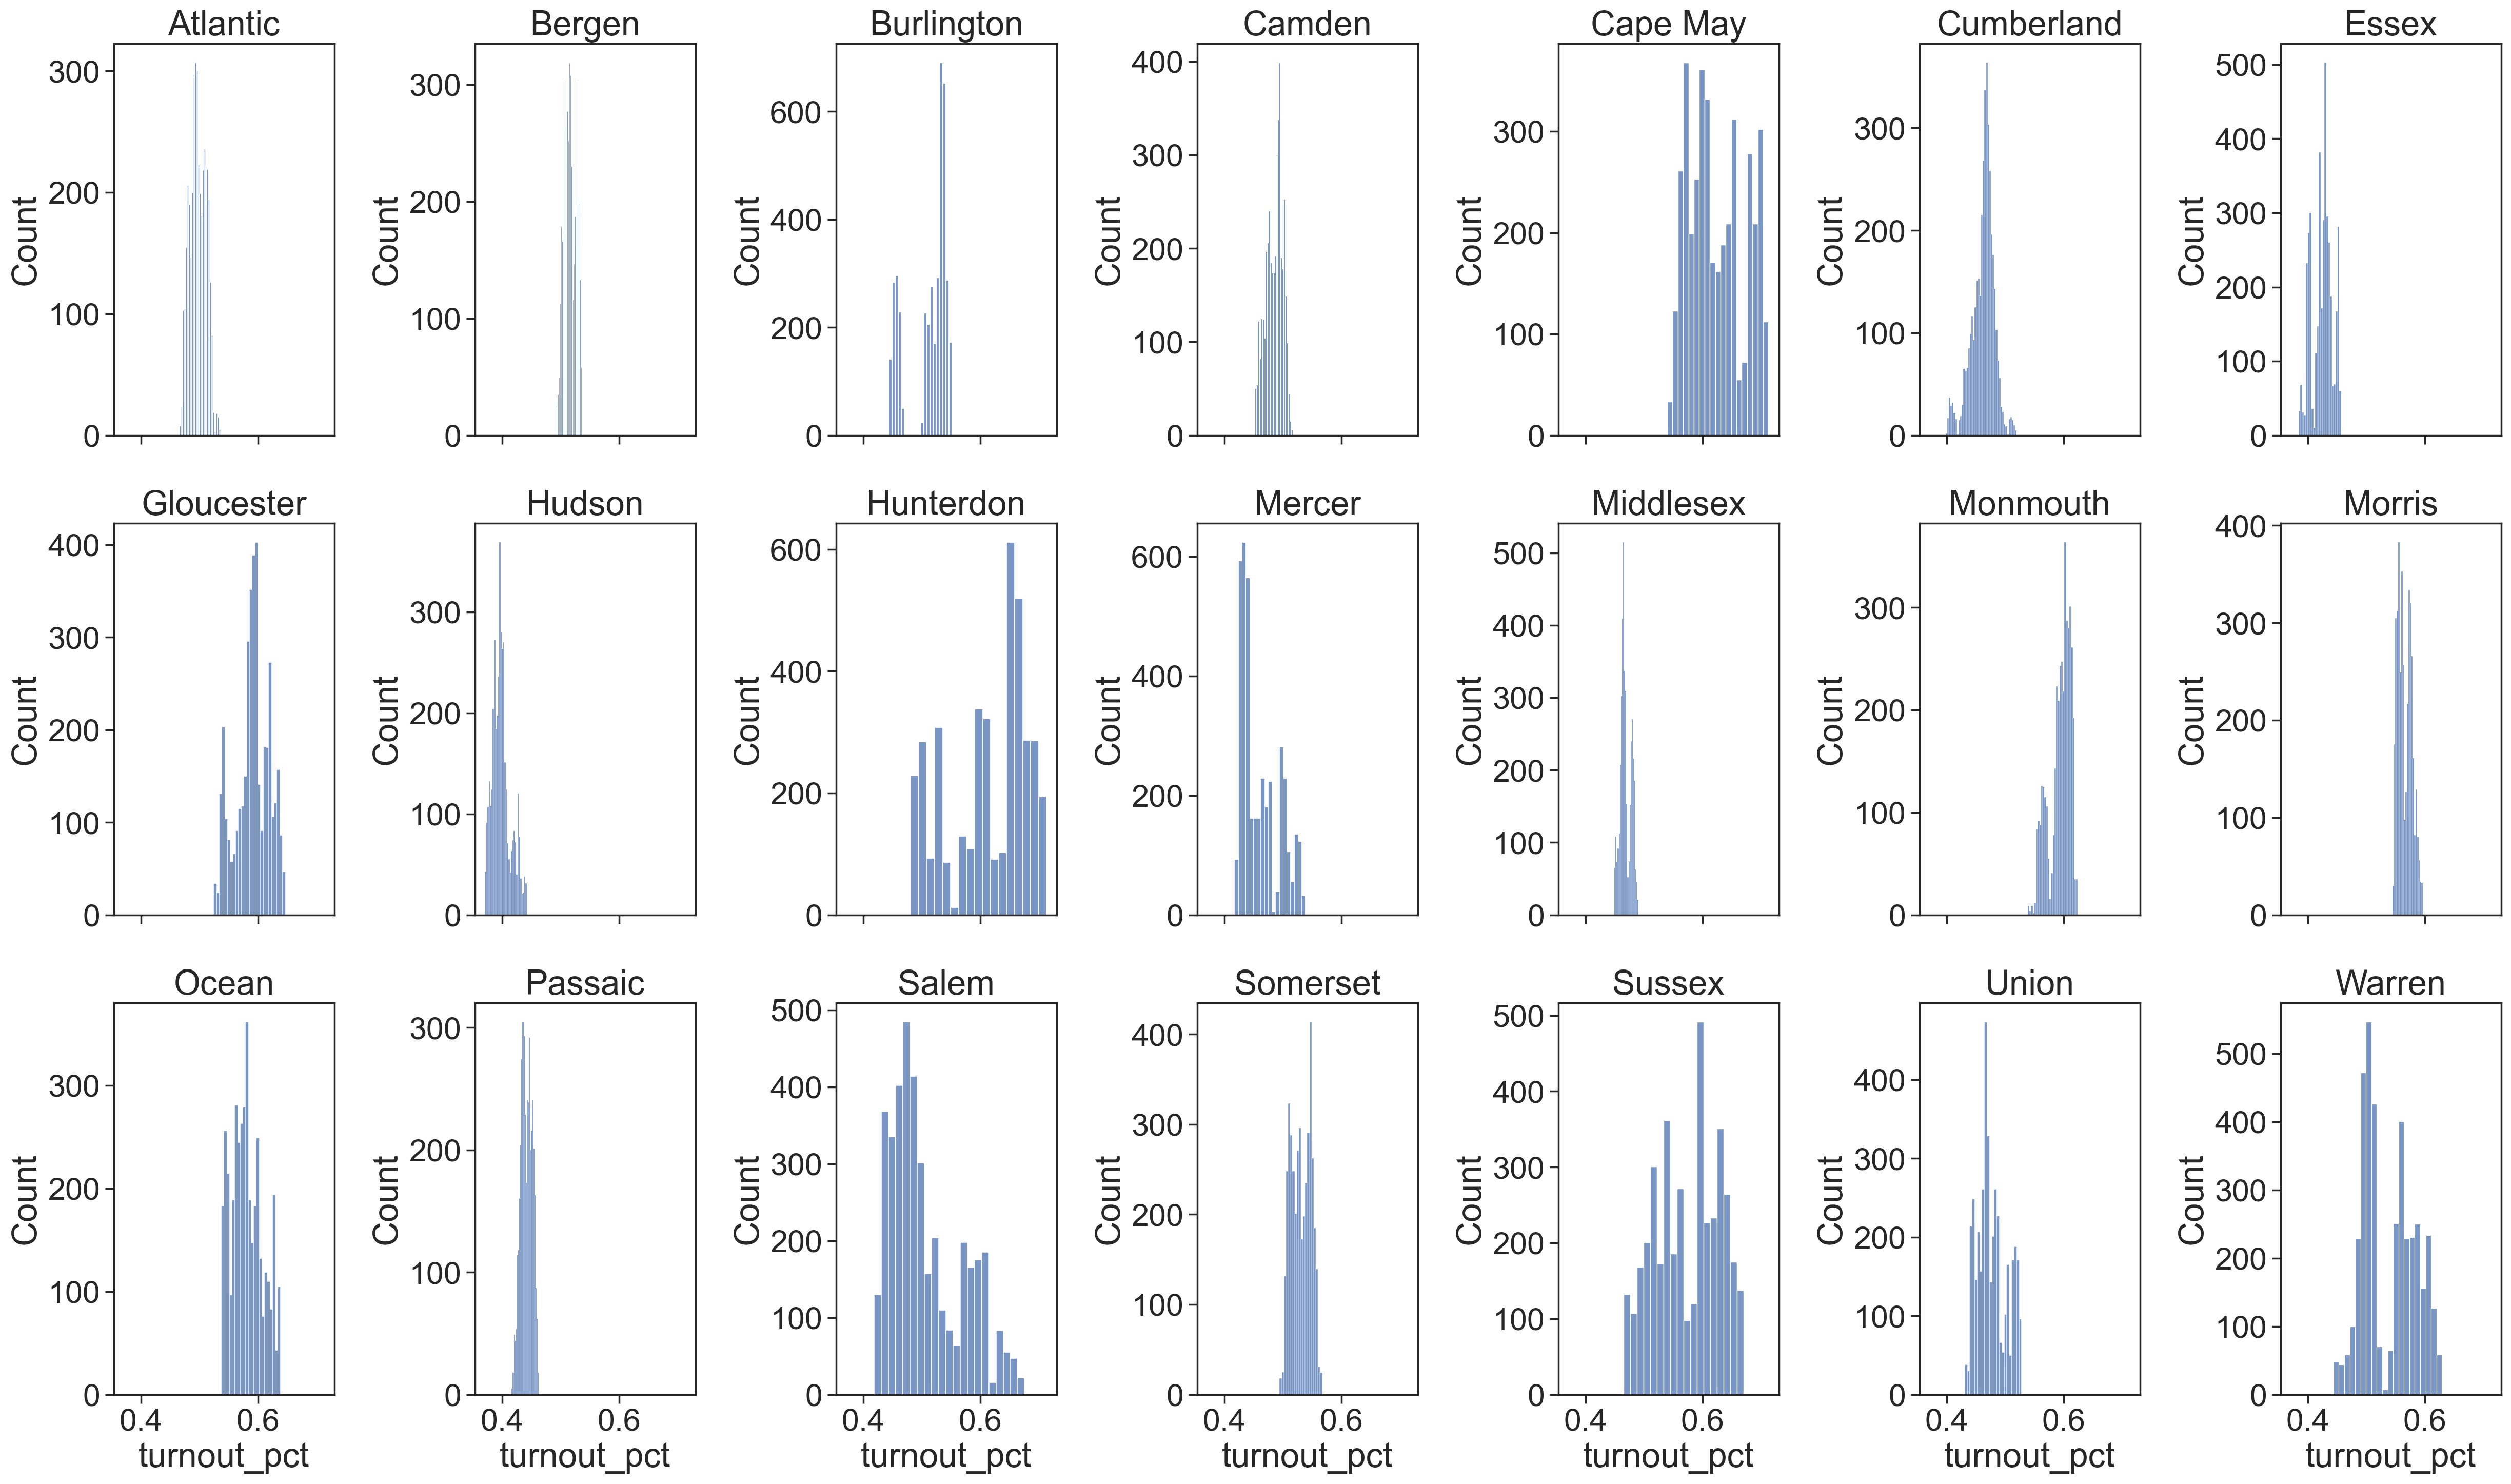

In [9]:
(fig, axs) = plt.subplots(3, 7, sharex=True, sharey=False)

for (c, ax) in zip(idata.posterior.coords["county"], axs.flatten()):
    post = idata.posterior.sel(county=c)["turnout_pct"].stack(sample=("chain", "draw"))
    sns.histplot(x=post, ax=ax)
    ax.set_title(str(c.values))

plt.tight_layout()

In [10]:
rows = []
for c in idata.posterior.coords["county"]:
    post = idata.posterior.sel(county=c)["turnout"].stack(sample=("chain", "draw"))
    row = {"County" : str(c.values),
           "Pred" : np.mean(post.values).round(0),
           "Lower" : np.quantile(post.values, 0.025).round(0),
           "Upper" : np.quantile(post.values, 0.975).round(0)}
    rows.append(row)
pandas.DataFrame(rows)

,County,Pred,Lower,Upper
0,Atlantic,101041.0,96098.0,105836.0
1,Bergen,348718.0,336865.0,360435.0
2,Burlington,187170.0,163625.0,200578.0
3,Camden,187925.0,177168.0,196656.0
4,Cape May,47628.0,42292.0,53643.0
5,Cumberland,44309.0,39328.0,47530.0
6,Essex,239377.0,220044.0,255493.0
7,Gloucester,133969.0,121510.0,144708.0
8,Hudson,169666.0,159158.0,184797.0
9,Hunterdon,65168.0,52035.0,75057.0


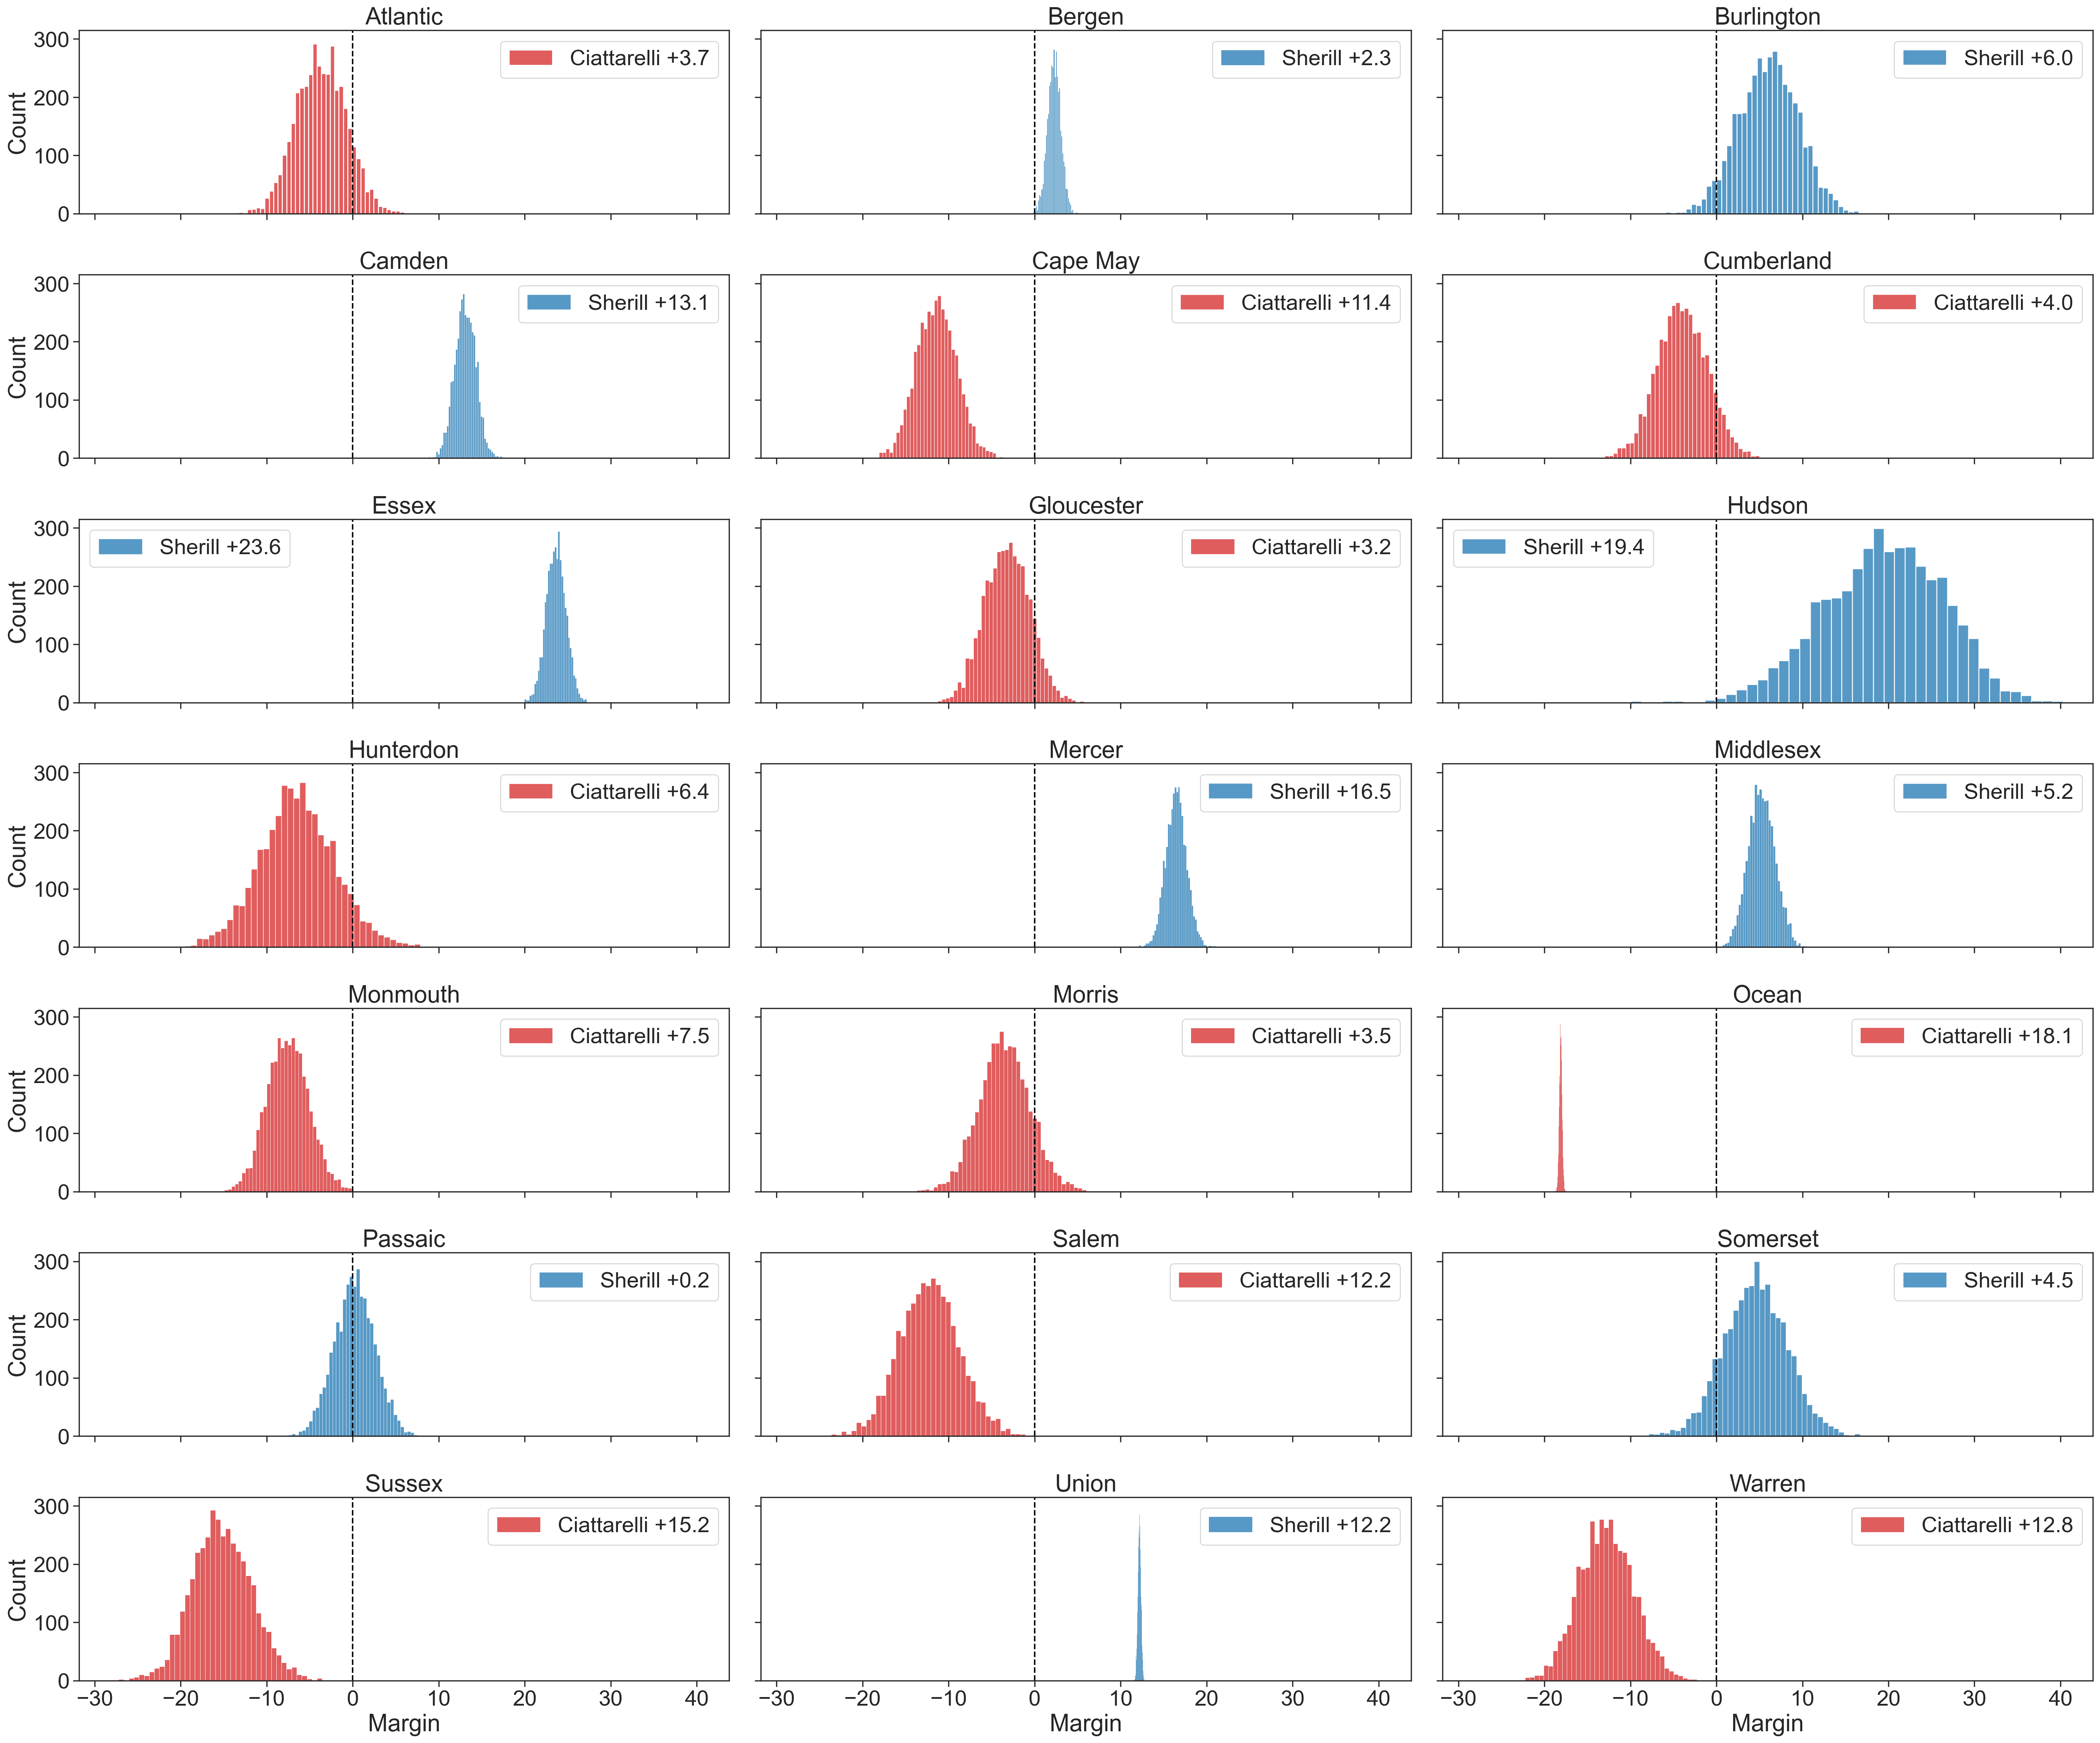

In [36]:
rows = []
(fig, axs) = plt.subplots(7, 3, sharex=True, sharey=True)
fig.set_size_inches(30, 25)

for (c, ax) in zip(idata.posterior.coords["county"], axs.flatten()):
    post = idata.posterior.sel(county=c)["prior_pct_D"].stack(sample=("chain", "draw"))
    margin = (post - 0.5) * 100
    row = {"County" : str(c.values),
           "Pred" : np.mean(margin.values),
           "Lower" : np.quantile(margin.values, 0.025),
           "Upper" : np.quantile(margin.values, 0.975)}
    rows.append(row)
    mean_margin = np.mean(margin.values).mean()

    if mean_margin > 0:
        sns.histplot(x=margin, ax=ax, color="tab:blue", label=f"Sherill +{np.round(mean_margin, 1)}")
    else:
        sns.histplot(x=margin, ax=ax, color="tab:red", label=f"Ciattarelli +{np.round(mean_margin, 1) * -1}")
    
    ax.set_title(str(c.values))
    ax.set_xlabel("Margin")
    ax.legend()
    ax.axvline(0, linestyle="--", color="black")

plt.tight_layout()

In [12]:
pandas.DataFrame(rows).round(1)

,County,Pred,Lower,Upper
0,Atlantic,-3.7,-9.3,2.0
1,Bergen,2.3,0.7,3.8
2,Burlington,6.0,-0.7,12.7
3,Camden,13.1,10.7,15.4
4,Cape May,-11.4,-15.8,-6.9
5,Cumberland,-4.0,-9.6,1.6
6,Essex,23.6,21.4,25.9
7,Gloucester,-3.2,-8.2,1.9
8,Hudson,19.4,5.4,31.8
9,Hunterdon,-6.4,-14.9,2.4


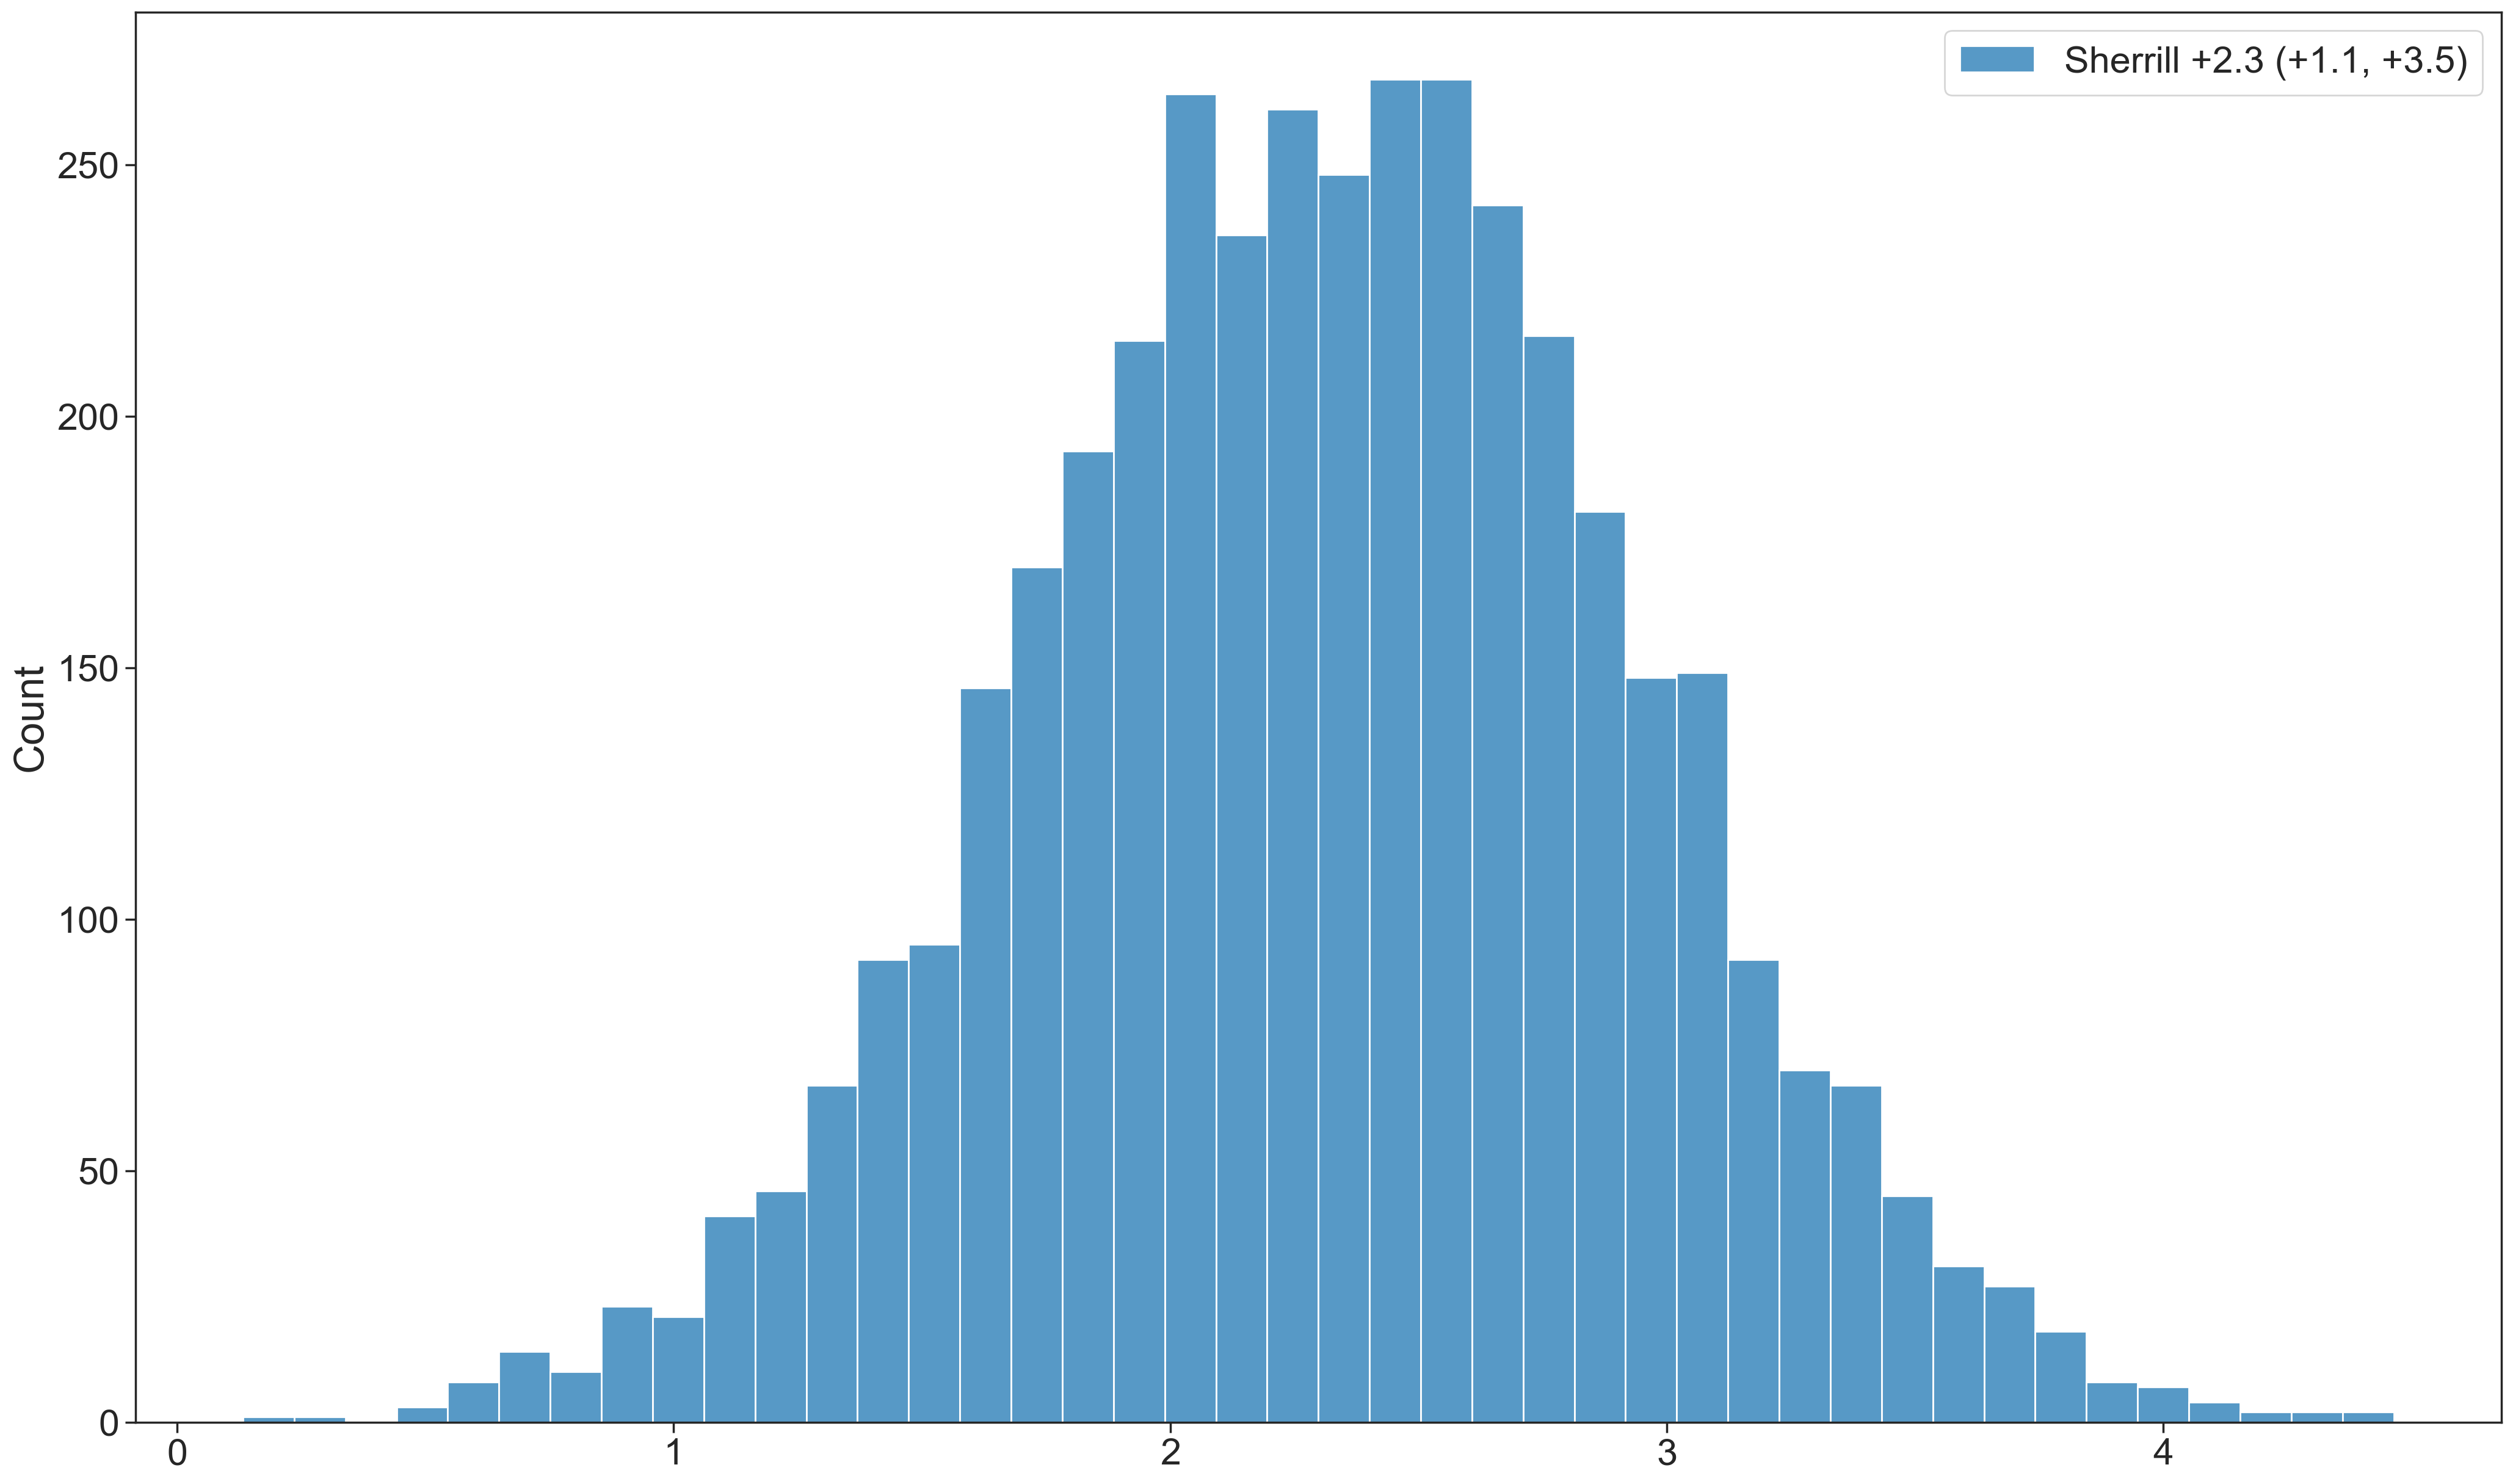

In [43]:
state_turnout = None
state_votes_D = None

for c in idata.posterior.coords["county"]:
    post_turnout = idata.posterior.sel(county=c)["turnout"].stack(sample=("chain", "draw"))
    post_pct_D = idata.posterior.sel(county=c)["prior_pct_D"].stack(sample=("chain", "draw"))
    votes_D = post_pct_D * post_turnout
    if state_turnout is None and state_votes_D is None:
        state_turnout = post_turnout.values
        state_votes_D = votes_D.values
    else:
        state_turnout = state_turnout + post_turnout.values
        state_votes_D = state_votes_D + votes_D.values

state_pct_D = state_votes_D / state_turnout
state_margin = (state_pct_D - 0.5) * 100
state_margin_lower = np.quantile(state_margin, 0.025)
state_margin_upper = np.quantile(state_margin, 0.975)

label = f"Sherrill +{state_margin.mean().round(1)} (+{state_margin_lower.round(1)}, +{state_margin_upper.round(1)})"

ax = sns.histplot(x=state_margin, label=label, color="tab:blue")
# ax.axvline(state_margin_lower, linestyle="--", color="black", label=f"Lower ")
# ax.axvline(state_margin_upper, linestyle="--", color="black", label=f"Upper ")
ax.legend()
plt.show()